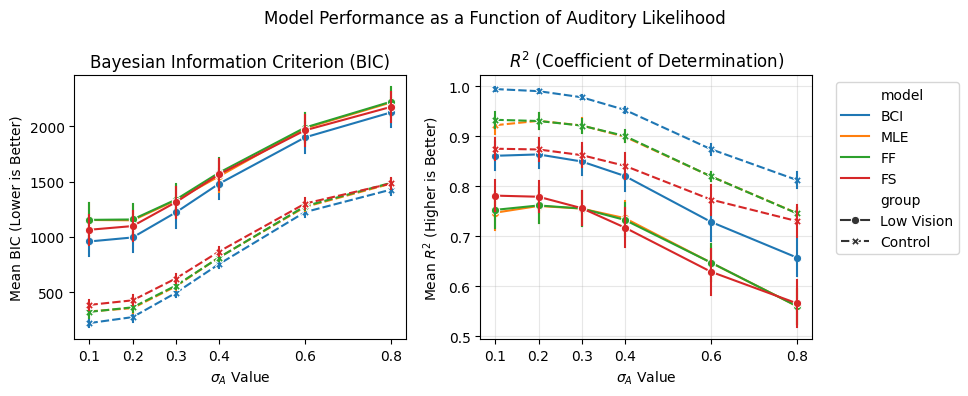

Group: Low Vision
Comparison: sigma_A = 0.1 vs 0.2
  BIC p = 0.000 | Mean: 1082.64±650.56 vs 1100.14±621.52
  R2  p = 0.596 | Mean: 0.79±0.15 vs 0.79±0.15
Comparison: sigma_A = 0.3 vs 0.2
  BIC p = 0.000 | Mean: 1299.78±633.32 vs 1100.14±621.52
  R2  p = 0.000 | Mean: 0.78±0.15 vs 0.79±0.15
Group: Control
Comparison: sigma_A = 0.1 vs 0.2
  BIC p = 0.000 | Mean: 314.25±223.85 vs 355.66±208.87
  R2  p = 0.000 | Mean: 0.93±0.08 vs 0.93±0.08
Comparison: sigma_A = 0.3 vs 0.2
  BIC p = 0.000 | Mean: 557.31±164.64 vs 355.66±208.87
  R2  p = 0.000 | Mean: 0.92±0.08 vs 0.93±0.08


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# compare BIC scores by sigma_a values
model_order = ['BCI', 'MLE', 'FF', 'FS']
groups = ['Control', 'Low Vision']
sigma_as = [0.1, 0.2, 0.3, 0.4, 0.6, 0.8]

all_results = []

for sigma_a in sigma_as:
    output_dir = f'csv/modeling/outputs/sigma_a_p{int(sigma_a*10)}/'
    for model in model_order:
        best_df = pd.read_csv(f'{output_dir}{model}_best_models.csv')
        # only look at 'raw' location rows
        raw_df = best_df[best_df['location'] == 'raw'].copy()
        raw_df = raw_df.reset_index()
        
        raw_df['model'] = model
        raw_df['sigma_a'] = sigma_a
        
        all_results.append(raw_df)

final_df = pd.concat(all_results, ignore_index=True)

fig, ax = plt.subplots(ncols=2, figsize=(10, 4))

for i, dv in enumerate(['bic', 'r2']):
    sns.lineplot(
        data=final_df, 
        x='sigma_a', 
        y=dv, 
        hue='model', 
        style='group', 
        markers=True, 
        dashes=True,
        errorbar='se',
        err_style='bars',
        ax=ax[i],
        legend=False if i==0 else True
    )
    ax[i].set_xlabel(r'$\sigma_A$ Value')
    ax[i].set_xticks([.1, .2, .3, .4, .6, .8])

ax[0].set_title('Bayesian Information Criterion (BIC)')
ax[0].set_ylabel('Mean BIC (Lower is Better)')
ax[1].set_title(r'$R^2$ (Coefficient of Determination)')
ax[1].set_ylabel(r'Mean $R^2$ (Higher is Better)')

plt.suptitle('Model Performance as a Function of Auditory Likelihood')
ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 0.98, 1])
plt.grid(True, alpha=0.3)
plt.show()

for group in ['Low Vision', 'Control']:
    print(f'Group: {group}')
    data_01 = final_df[(final_df['sigma_a'] == 0.1) & (final_df['group'] == group)]
    data_02 = final_df[(final_df['sigma_a'] == 0.2) & (final_df['group'] == group)]
    data_03 = final_df[(final_df['sigma_a'] == 0.3) & (final_df['group'] == group)]

    data_01 = data_01.sort_values('subject_id')
    data_02 = data_02.sort_values('subject_id')
    data_03 = data_03.sort_values('subject_id')

    for label, data_compare in zip(['sigma_A = 0.1 vs 0.2', 'sigma_A = 0.3 vs 0.2'], [data_01, data_03]):
        stat_bic, p_bic = wilcoxon(data_compare['bic'], data_02['bic'])
        stat_r2, p_r2 = wilcoxon(data_compare['r2'], data_02['r2'])

        print(f"Comparison: {label}")
        m1, s1 = data_compare['bic'].mean(), data_compare['bic'].std()
        m2, s2 = data_02['bic'].mean(), data_02['bic'].std()        
        print(f"  BIC p = {min(p_bic * 8, 1.0):.3f} | Mean: {m1:.2f}±{s1:.2f} vs {m2:.2f}±{s2:.2f}")
        m1, s1 = data_compare['r2'].mean(), data_compare['r2'].std()
        m2, s2 = data_02['r2'].mean(), data_02['r2'].std()        
        print(f"  R2  p = {min(p_r2 * 8, 1.0):.3f} | Mean: {m1:.2f}±{s1:.2f} vs {m2:.2f}±{s2:.2f}")
